# Практика: логистическая регрессия с нуля и сравнение со `scikit-learn`

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и изучите бинарный датасет;
2. подготовите данные для обучения;
3. реализуете ключевые части логистической регрессии **с нуля**:
   - сигмоиду,
   - log-loss,
   - градиентный спуск,
   - предсказание вероятностей и классов;
4. обучите свою модель;
5. сравните её качество и коэффициенты с реализацией из `scikit-learn`;
6. поэкспериментируете с порогом классификации.

## Важно
- Сначала дописывайте пропуски в **своей** реализации.
- Только после этого переходите к сравнению со `scikit-learn`.
- Не удаляйте проверки и комментарии: они помогают вам понять ход решения.

## Датасет
Мы используем `Breast Cancer Wisconsin` из `sklearn.datasets`:
- задача **бинарной классификации**;
- признаки числовые;
- датасет удобен для изучения логистической регрессии без сложной предобработки категориальных переменных.

## Что сдавать
1. Заполненный ноутбук.
2. Краткие выводы в конце:
   - насколько близки метрики вашей модели и `scikit-learn`;
   - где ваша реализация может уступать библиотечной;
   - как влияет изменение порога классификации.

## Коротко о теории

### 1. Логистическая регрессия
Логистическая регрессия моделирует вероятность положительного класса:

$
P(y=1 \mid x) = \sigma(z), \quad z = w^T x + b
$

где \(\sigma(z)\) — сигмоида:

$
\sigma(z) = \frac{1}{1 + e^{-z}}
$

### 2. Почему не линейная регрессия
Если предсказывать класс линейной моделью напрямую, прогноз может выйти за диапазон \([0, 1]\).  
Сигмоида решает эту проблему: она переводит любое число в вероятность.

### 3. Функция потерь
Для логистической регрессии используется **log-loss**:

$
L = - \frac{1}{n} \sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)
\right]
$

### 4. Обучение
Мы будем минимизировать log-loss методом **градиентного спуска**.

### 5. Что будем сравнивать
После своей реализации вы сравните результат с `sklearn.linear_model.LogisticRegression`:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

### 6. Почему нужна стандартизация
Градиентный спуск работает стабильнее, когда признаки находятся примерно в одном масштабе.

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)

In [36]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Размер X:", X.shape)
print("Размер y:", y.shape)
display(X.head())
display(y.value_counts().rename(index={0: "malignant", 1: "benign"}))

Размер X: (569, 30)
Размер y: (569,)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,count
target,
benign,357
malignant,212


Пропуски по признакам:


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0



Базовая статистика:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


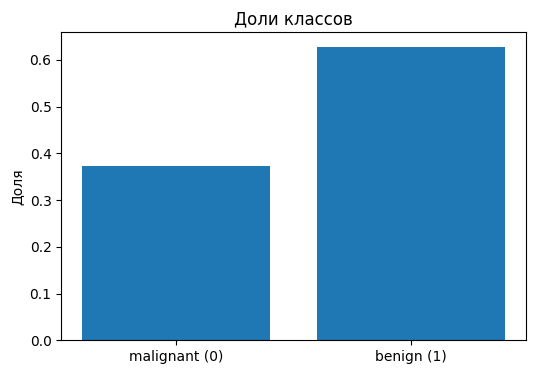

In [37]:
print("Пропуски по признакам:")
display(X.isna().sum().sort_values(ascending=False).head())

print("\nБазовая статистика:")
display(X.describe().T.head(10))

class_share = y.value_counts(normalize=True).sort_index()
plt.figure(figsize=(6, 4))
plt.bar(["malignant (0)", "benign (1)"], class_share.values)
plt.title("Доли классов")
plt.ylabel("Доля")
plt.show()

## Шаг 1. Разделение данных и стандартизация

Ниже нужно:
1. разбить выборку на train и test;
2. стандартизовать признаки только по train-части;
3. получить `X_train_scaled` и `X_test_scaled`.

Подсказка:
- используйте `train_test_split(..., test_size=0.2, random_state=42, stratify=y)`;
- `StandardScaler().fit(...)` делаем **только на train**.

In [38]:
# YOUR CODE HERE
# 1) Разбейте данные на train/test
# 2) Создайте scaler
# 3) Обучите scaler на train
# 4) Преобразуйте X_train и X_test

X_train, X_test, y_train, y_test =train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
#Для нормального распределения на y  признаков 0 и 1 stratify
scaler = StandardScaler()
X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (455, 30)
Test shape: (114, 30)


## Шаг 2. Реализуем сигмоиду

Допишите функцию `sigmoid(z)`.

Проверка:
- `sigmoid(0)` должно быть равно `0.5`;
- функция должна работать и со скалярами, и с `numpy`-массивами.

In [39]:
def sigmoid(z):
  return 1/(1+np.exp(-z))


print("sigmoid(0) =", sigmoid(0))
print("sigmoid([-1, 0, 1]) =", sigmoid(np.array([-1.0, 0.0, 1.0])))

sigmoid(0) = 0.5
sigmoid([-1, 0, 1]) = [0.26894142 0.5        0.73105858]


## Шаг 3. Реализуем log-loss

Напишите функцию `compute_log_loss(y_true, y_pred_proba)`.

Важно:
- чтобы избежать `log(0)`, используйте `np.clip(y_pred_proba, 1e-15, 1 - 1e-15)`.

In [60]:
def compute_log_loss(y_true, y_pred_proba):
    # YOUR CODE HERE
    x_pred_prob=np.clip(y_pred_proba,1e-16,1-1e-15) # обход значения log(0)
    loss=-np.mean(np.log(y_pred_proba)*y_true +(1-y_true)*np.log(1-y_pred_proba))
    return loss
    # y_pred_proba  это наша вероятность

toy_y = np.array([0, 1, 1, 0])
toy_p = np.array([0.1, 0.9, 0.8, 0.3])
print("Toy log-loss:", compute_log_loss(toy_y, toy_p))

Toy log-loss: 0.19763488164214868


## Шаг 4. Один шаг градиентного спуска

Напомним:
- \(z = Xw + b\)
- $\hat{p} = \sigma(z)$

Градиенты для log-loss:
\[$
dw =
rac{1}{n} X^T(\hat{p} - y), \qquad db =
rac{1}{n}\sum(\hat{p} - y)
$\]

Ниже нужно реализовать функцию, которая считает:
- вероятности,
- loss,
- градиенты `dw`, `db`.

In [41]:
def forward_backward(X, y, w, b):
    # YOUR CODE HERE
    # 1) посчитать z
    # 2) посчитать p = sigmoid(z)
    # 3) посчитать loss
    # 4) посчитать dw и db
    z=X@w+b
    p= 1 /(1+np.exp(-z))
    loss=compute_log_loss(y,p)
    dw=(X.T @(p-y))/ X.shape[0] # средний градиент весов
    db=np.mean(p-y) # градиент смещения
    # Обновление весов ->  просто считаем среднее тк если все 1 мы придем к среднему
    # По все объектам

    return p, loss, dw, db
    # Один из весов
 # Не инициализировать нулями
n_features = X_train_scaled.shape[1]
w0 = np.zeros(n_features)
b0 = 0.0

p0, loss0, dw0, db0 = forward_backward(X_train_scaled, y_train.values, w0, b0)
print("Initial loss:", loss0)
print("dw shape:", dw0.shape)
print("db:", db0)

Initial loss: 0.6931471805599453
dw shape: (30,)
db: -0.12637362637362637


## Шаг 5. Собираем модель в класс

Допишите методы:
- `fit`
- `predict_proba`
- `predict`

Требования:
- обучение через градиентный спуск;
- сохранять историю значения loss;
- в `predict` использовать порог `threshold`.

In [42]:
class MyLogisticRegressionGD:
    def __init__(self, learning_rate=0.05, n_iters=3000, threshold=0.5):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.w = None
        self.b = None
        self.loss_history = []

    def fit(self, X, y):
        # YOUR CODE HERE
        # 1) инициализируйте w и b
        # 2) в цикле вызовите forward_backward
        # 3) обновите параметры
        # 4) сохраните loss в self.loss_history
        #Цикл обучения : посчит первый лос отнимем от весов и вернемся в начало
        n_features = X.shape[1]
        self.w=np.random.rand(n_features)*0.01
        self.b=0.0
        self.loss_history=[]

        for i in range(self.n_iters):
          p,loss,dw,db=forward_backward(X,y,self.w,self.b)

          self.loss_history.append(loss)

          self.w = self.w - self.learning_rate * dw
          self.b = self.b - self.learning_rate * db
          # learning_rate  гиперпараметр определяющий длину шага для обновления весов

        #можно нулями (можно рандомно)
        #порог по лосу early_stoping

          if i % 100 == 0:
            print(f"Iteration {i}, Loss: {loss}")
          if loss < 1e-6:
            break

        return self

    def my_predict_proba(self, X):
        # YOUR CODE HERE
        z=X@ self.w +self.b
        proba=1/(1+np.exp(-z))

        return proba
        # массив вероятностей

    def my_predict(self, X):
        # YOUR CODE HERE
        proba=self.my_predict_proba(X)
        preds=(proba>=self.threshold).astype(int)
        # treshhold порог -> рез булевый массив->  преобразуем в 0,1
        return preds

## Шаг 6. Обучаем свою модель

Попробуйте обучить свою модель и посмотрите:
- уменьшается ли `loss`;
- какое качество получается на test.

Iteration 0, Loss: 0.7240450924546133
Iteration 100, Loss: 0.12562406301471055
Iteration 200, Loss: 0.09856968501968745
Iteration 300, Loss: 0.08696725221184948
Iteration 400, Loss: 0.08018627833584666
Iteration 500, Loss: 0.075621762718011
Iteration 600, Loss: 0.07228426736955705
Iteration 700, Loss: 0.06970677892535564
Iteration 800, Loss: 0.06763735118204037
Iteration 900, Loss: 0.06592696895043108
Iteration 1000, Loss: 0.06448131377624039
Iteration 1100, Loss: 0.06323748091178677
Iteration 1200, Loss: 0.062151729559656525
Iteration 1300, Loss: 0.06119258973896573
Iteration 1400, Loss: 0.060336767418972856
Iteration 1500, Loss: 0.059566600692714945
Iteration 1600, Loss: 0.05886841892854484
Iteration 1700, Loss: 0.05823144985009759
Iteration 1800, Loss: 0.057647071109773414
Iteration 1900, Loss: 0.05710828521780366
Iteration 2000, Loss: 0.05660934323863773
Iteration 2100, Loss: 0.05614546995826437
Iteration 2200, Loss: 0.055712659740614484
Iteration 2300, Loss: 0.05530752256849399
It

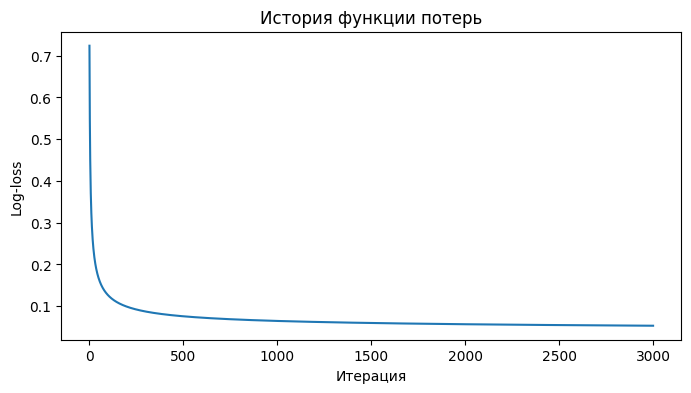

In [43]:
my_model = MyLogisticRegressionGD(
    learning_rate=0.05,   # подберите разумное значение
    n_iters=3000,         # задайте число итераций
    threshold=0.5
)

# YOUR CODE HERE
# обучите модель
my_model.fit(X_train_scaled,y_train)

plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.show()

Потери уменьшаются, с достижением минимума. Loss падает быстро, что довольно хорошо. График стабильный

## Шаг 7. Оценка качества своей модели

Заполните код ниже и посчитайте:
- accuracy,
- precision,
- recall,
- f1,
- ROC-AUC.

Подсказка:
- для ROC-AUC нужны **вероятности**, а не классы.

In [44]:
# YOUR CODE HERE
my_proba_test = my_model.my_predict_proba(X_test_scaled)
my_pred_test = my_model.my_predict(X_test_scaled)

my_metrics = {
    "accuracy": accuracy_score(y_test, my_pred_test),
    "precision": precision_score(y_test, my_pred_test),
    "recall": recall_score(y_test, my_pred_test),
    "f1": f1_score(y_test, my_pred_test),
    "roc_auc": roc_auc_score(y_test, my_proba_test),
}

pd.Series(my_metrics).round(4)

,0
accuracy,0.9825
precision,0.9861
recall,0.9861
f1,0.9861
roc_auc,0.9950


## Шаг 8. Confusion matrix и ROC-кривая

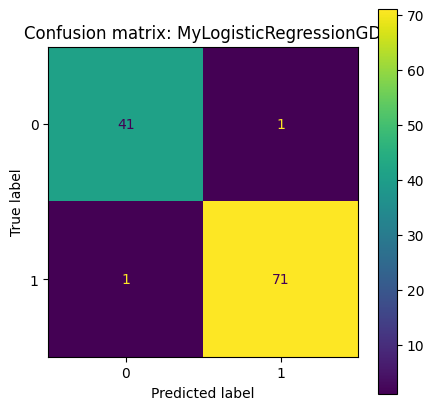

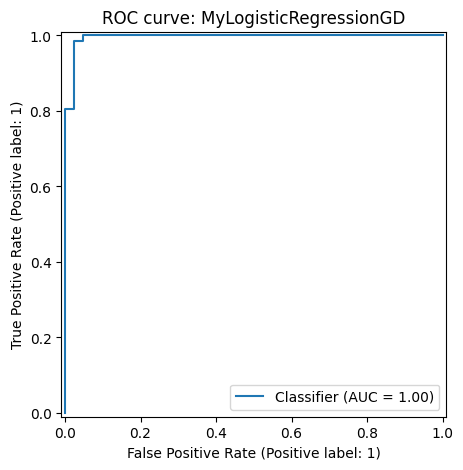

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [45]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, my_pred_test, ax=ax)
plt.title("Confusion matrix: MyLogisticRegressionGD")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, my_proba_test, ax=ax)
plt.title("ROC curve: MyLogisticRegressionGD")
plt.show()

print(classification_report(y_test, my_pred_test))

## Шаг 9. Сравнение с `scikit-learn`

Теперь обучите библиотечную модель и сравните её с вашей реализацией.

Рекомендации:
- используйте `LogisticRegression(max_iter=1000)`;
- обучайте на тех же стандартизованных данных.

In [58]:
sk_model = LogisticRegression(max_iter=1000)

# YOUR CODE HERE
# 1) обучите sk_model
# 2) получите вероятности и классы на test
# 3) посчитайте те же метрики
...
sk_model.fit(X_train_scaled,y_train)
prob_test=sk_model.predict_proba(X_test_scaled)
pred_test=sk_model.predict(X_test_scaled)
sk_metrics = {
    "accuracy": accuracy_score(y_test,pred_test),
    "precision":precision_score(y_test,pred_test),
    "recall": recall_score(y_test,pred_test),
    "f1": f1_score(y_test,pred_test),
    "roc_auc": roc_auc_score(y_test,pred_test),
}

pd.Series(sk_metrics).round(4)

,0
accuracy,0.9825
precision,0.9861
recall,0.9861
f1,0.9861
roc_auc,0.9812


## Шаг 10. Сводная таблица сравнения

Сравните:
1. свою реализацию;
2. `scikit-learn`.

Подумайте:
- почему результаты могут быть немного разными;
- что в библиотечной реализации сделано устойчивее.

In [47]:
comparison = pd.DataFrame([my_metrics, sk_metrics], index=["my_model", "sklearn"])
display(comparison.round(4))

coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "my_coef": my_model.w,
    "sklearn_coef": sk_model.coef_.ravel(),
})
coef_comparison["abs_diff"] = np.abs(coef_comparison["my_coef"] - coef_comparison["sklearn_coef"])
display(coef_comparison.sort_values("abs_diff", ascending=False).head(10))

,accuracy,precision,recall,f1,roc_auc
my_model,0.9825,0.9861,0.9861,0.9861,0.9950
sklearn,0.9825,0.9861,0.9861,0.9861,0.9812


,feature,my_coef,sklearn_coef,abs_diff
5,mean compactness,0.266523,0.648342,0.381818
1,mean texture,-0.763842,-0.552698,0.211144
9,mean fractal dimension,0.401875,0.199732,0.202143
25,worst compactness,-0.096315,0.055514,0.151829
10,radius error,-0.937883,-1.082965,0.145082
21,worst texture,-1.118136,-1.255088,0.136952
17,concave points error,-0.315898,-0.443784,0.127887
26,worst concavity,-0.696689,-0.823151,0.126461
13,area error,-0.807792,-0.929104,0.121312
2,mean perimeter,-0.594325,-0.476298,0.118027


1) Результаты разняться, потому что scikit-learn библеотека более мощная по методам обработки и более обширная. В собственной реализации используется градиентный спуск, для которого мы используем и большее колличесвто иттреаций и при котором, могут получится другие локальные минимумы. Так же в коде есть early_ranning, который может преостановить выполнение при достигнутом колличестве иттераций.Веса также могут распределятся по разному.

2) Численная стабильность,
$loss=max(0,z)−z⋅y+log(1+e
−∣z∣
 )$

 Проверка сходимости к нужному значению
 Для регулизации параметр для вычисления штрафа 'C'=1.0
 используется LBFGS, ане GD.

## Шаг 11. Эксперимент с порогом классификации

По умолчанию обычно берут порог `0.5`, но это не всегда лучший выбор.

Ниже нужно сравнить метрики при порогах:
- 0.3
- 0.5
- 0.7

Подсказка:
- `pred = (proba >= threshold).astype(int)`

In [59]:
thresholds = [0.3, 0.5, 0.7]
rows = []

for threshold in thresholds:
    # YOUR CODE HERE
    pred_thr =(prob_test[:, 1] >= threshold).astype(int)
    rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred_thr),
        "precision": precision_score(y_test, pred_thr),
        "recall": recall_score(y_test, pred_thr),
        "f1":f1_score(y_test, pred_thr),
    })

pd.DataFrame(rows).round(4)

,threshold,accuracy,precision,recall,f1
0,0.3,0.9825,0.9730,1.0000,0.9863
1,0.5,0.9825,0.9861,0.9861,0.9861
2,0.7,0.9561,0.9855,0.9444,0.9645


## Финальные вопросы для ответа текстом

Ответьте кратко, но по существу.

1. **Почему для логистической регрессии используется сигмоида?**
Сжимает любое число z  в интервал(0,1). Показывает вероятность.
Если предсказывать класс линейной моделью напрямую, прогноз может выйти за диапазон \([0, 1]\).  
Сигмоида решает эту проблему: она переводит любое число в вероятность.
2. **Почему в этой задаче мы считаем **log-loss**, а не MSE?**
MSE не выдаст оптимальные штрафы предсказаниям. Функция будет не выпуклой, с большим колличесввом локальных минимумов
3. **Зачем стандартизировать признаки перед обучением градиентным спуском?**
Без стандартизации график может скакать, выдавать не корректные значения, либо обнулять их. Нуждается в большом колличестве иттераций.
При стандартизации быстрая сходимость, стабильность результата, единый шаг обучения, мы можем сравнивать разные признаки между собой, градиент будет хорошо вычисляться.
4. **Насколько близки метрики вашей реализации к `scikit-learn`?**

Метри моей реализации равны библеотечной, только есть небольшая разница в roc_auc.

5. **Почему библиотечная модель обычно работает стабильнее и быстрее?**

Используется другой метод поиска локального минимума.

6. **Как изменение порога влияет на precision и recall?**

При увеличении порога Precision растет выделяя больше FN,а Recall уменьшается пропуская положительные значения
Наоборот растёт Recall, падает Precision.

7. **В каких задачах логистическая регрессия особенно хороша, а где может уступать более сложным моделям?**

Лучшее: в задачах понятия фактора риска (медицина, банк). Где мало данных. Для простых классификаций. В задачах, где важно скорость обработки.
Другие модели: Большие обЪёмы данных, неструктурированные данные, влияние признаков друг на друга

## Дополнительные задания

### Задание A
Добавьте L2-регуляризацию в свою реализацию.

### Задание B
Постройте таблицу с 10 признаками, которые дают наибольший по модулю вклад в модель.

### Задание C
Попробуйте:
- уменьшить число итераций;
- изменить `learning_rate`;
- посмотреть, как это влияет на сходимость и метрики.

#Задание А Регулязация


In [61]:
class MyLogisticRegressionGD:
    def __init__(self, learning_rate=0.05, n_iters=3000, threshold=0.5, penalty=None, reg_lambda=0.01):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.threshold = threshold
        self.penalty = penalty
        self.reg_lambda = reg_lambda
        self.w = None
        self.b = None
        self.loss_history = []

    def calculate_loss_and_gradients(self, X, y):
        # Forward pass
        z = X @ self.w + self.b
        p = sigmoid(z)

        unreg_loss = compute_log_loss(y, p)

        dw = (X.T @ (p-y)) / X.shape[0]
        db = np.mean(p-y)

        current_loss = unreg_loss
        if self.penalty == 'l2' and self.reg_lambda > 0:
            # L2 :(lambda / (2 * N)) * sum(w^2)
            current_loss += (self.reg_lambda / (2 * X.shape[0])) * np.sum(self.w**2)
            # (lambda / N) * w
            dw += (self.reg_lambda / X.shape[0]) * self.w

        return p, current_loss, dw, db

    def fit(self, X, y):
        n_features = X.shape[1]
        self.w = np.random.rand(n_features) * 0.01
        self.b = 0.0
        self.loss_history = []

        for i in range(self.n_iters):
            p, current_loss, dw, db = self.calculate_loss_and_gradients(X, y)

            self.loss_history.append(current_loss)

            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

            if i % 100 == 0:
                print(f"Iteration {i}, Loss: {current_loss}")

            # if current_loss < 1e-6:
            #     break

        return self

    def my_predict_proba(self, X):
        z = X @ self.w + self.b
        proba = sigmoid(z)
        return proba

    def my_predict(self, X):
        proba = self.my_predict_proba(X)
        preds = (proba >= self.threshold).astype(int)
        return preds

Iteration 0, Loss: 0.7320352856425074


/tmp/ipykernel_2790/2817475561.py:4: RuntimeWarning: divide by zero encountered in log
  loss=-np.mean(np.log(y_pred_proba)*y_true +(1-y_true)*np.log(1-y_pred_proba))
/tmp/ipykernel_2790/2817475561.py:4: RuntimeWarning: divide by zero encountered in log
  loss=-np.mean(np.log(y_pred_proba)*y_true +(1-y_true)*np.log(1-y_pred_proba))
/tmp/ipykernel_2790/2817475561.py:4: RuntimeWarning: divide by zero encountered in log
  loss=-np.mean(np.log(y_pred_proba)*y_true +(1-y_true)*np.log(1-y_pred_proba))
/tmp/ipykernel_2790/2817475561.py:4: RuntimeWarning: divide by zero encountered in log
  loss=-np.mean(np.log(y_pred_proba)*y_true +(1-y_true)*np.log(1-y_pred_proba))
/tmp/ipykernel_2790/2817475561.py:4: RuntimeWarning: divide by zero encountered in log
  loss=-np.mean(np.log(y_pred_proba)*y_true +(1-y_true)*np.log(1-y_pred_proba))


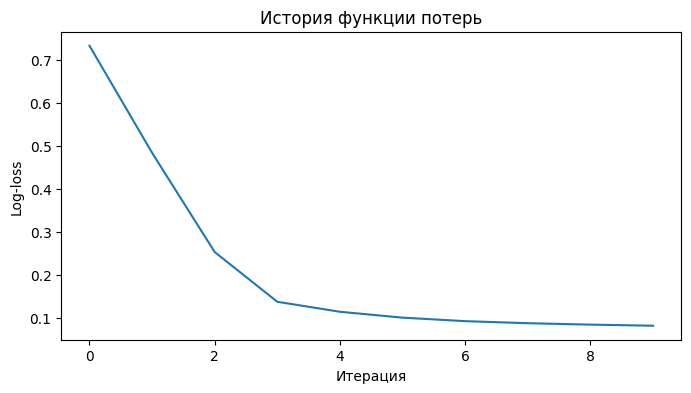

In [91]:
my_model = MyLogisticRegressionGD(
    learning_rate=5,   # подберите разумное значение
    n_iters=10,         # задайте число итераций
    threshold=0.5,
    penalty='l2',
    reg_lambda=0.01
)

# YOUR CODE HERE
# обучите модель
my_model.fit(X_train_scaled,y_train)

plt.figure(figsize=(8, 4))
plt.plot(my_model.loss_history)
plt.title("История функции потерь")
plt.xlabel("Итерация")
plt.ylabel("Log-loss")
plt.show()

In [92]:
# YOUR CODE HERE
my_proba_test = my_model.my_predict_proba(X_test_scaled)
my_pred_test = my_model.my_predict(X_test_scaled)

my_metrics = {
    "accuracy": accuracy_score(y_test, my_pred_test),
    "precision": precision_score(y_test, my_pred_test),
    "recall": recall_score(y_test, my_pred_test),
    "f1": f1_score(y_test, my_pred_test),
    "roc_auc": roc_auc_score(y_test, my_proba_test),
}

pd.Series(my_metrics).round(4)

,0
accuracy,0.9649
precision,0.9595
recall,0.9861
f1,0.9726
roc_auc,0.9954


In [93]:
comparison = pd.DataFrame([my_metrics, sk_metrics], index=["my_model", "sklearn"])
display(comparison.round(4))

coef_comparison = pd.DataFrame({
    "feature": X.columns,
    "my_coef": my_model.w,
    "sklearn_coef": sk_model.coef_.ravel(),
})
coef_comparison["abs_diff"] = np.abs(coef_comparison["my_coef"] - coef_comparison["sklearn_coef"])
display(coef_comparison.sort_values("abs_diff", ascending=False).head(10))

,accuracy,precision,recall,f1,roc_auc
my_model,0.9649,0.9595,0.9861,0.9726,0.9954
sklearn,0.9825,0.9861,0.9861,0.9861,0.9812


,feature,my_coef,sklearn_coef,abs_diff
5,mean compactness,-0.666425,0.648342,1.314767
2,mean perimeter,-1.777098,-0.476298,1.300800
0,mean radius,-1.792302,-0.511479,1.280823
3,mean area,-1.774807,-0.541059,1.233747
22,worst perimeter,-1.960673,-0.763220,1.197453
20,worst radius,-2.017579,-0.947616,1.069963
23,worst area,-1.956770,-0.947756,1.009014
1,mean texture,-1.541968,-0.552698,0.989270
7,mean concave points,-1.614829,-0.704156,0.910672
25,worst compactness,-0.821210,0.055514,0.876724


## Задание B: Признаки с наибольшим вкладом в модель

Вклад признака в модель логистической регрессии определяется абсолютным значением его коэффициента. Чем больше абсолютное значение коэффициента, тем сильнее этот признак влияет на вероятность отнесения объекта к положительному или отрицательному классу.

Построим таблицу с 10 признаками, которые имеют наибольшие абсолютные значения коэффициентов для обеих реализаций модели.

In [105]:
# Для scikit-learn
sk_weights=sk_model.coef_.ravel()
feature_imp_df=pd.DataFrame(
    {'feature':X.columns,
     'sk_learn_abs_coef':np.abs(sk_weights)}
)

display(feature_imp_df.sort_values(by='sk_learn_abs_coef',ascending=False).head(10))

,feature,sk_learn_abs_coef
21,worst texture,1.255088
10,radius error,1.082965
27,worst concave points,0.953686
23,worst area,0.947756
20,worst radius,0.947616
28,worst symmetry,0.939181
13,area error,0.929104
26,worst concavity,0.823151
22,worst perimeter,0.763220
24,worst smoothness,0.746625


In [106]:
my_model_weights = my_model.w

# Для sk_model (scikit-learn реализация):
sk_model_weights = sk_model.coef_.ravel()

# Создадим DataFrame для сравнения
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'my_model_abs_coef': np.abs(my_model_weights),
    'sklearn_abs_coef': np.abs(sk_model_weights)
})

print("Топ-10 признаков по абсолютному вкладу в вашу реализацию модели:")
display(feature_importance_df.sort_values(by='my_model_abs_coef', ascending=False).head(10))

print("\nТоп-10 признаков по абсолютному вкладу в модель scikit-learn:")
display(feature_importance_df.sort_values(by='sklearn_abs_coef', ascending=False).head(10))

Топ-10 признаков по абсолютному вкладу в вашу реализацию модели:


,feature,my_model_abs_coef,sklearn_abs_coef
20,worst radius,2.017579,0.947616
22,worst perimeter,1.960673,0.763220
23,worst area,1.956770,0.947756
0,mean radius,1.792302,0.511479
2,mean perimeter,1.777098,0.476298
21,worst texture,1.774996,1.255088
3,mean area,1.774807,0.541059
27,worst concave points,1.710361,0.953686
7,mean concave points,1.614829,0.704156
1,mean texture,1.541968,0.552698



Топ-10 признаков по абсолютному вкладу в модель scikit-learn:


,feature,my_model_abs_coef,sklearn_abs_coef
21,worst texture,1.774996,1.255088
10,radius error,1.446963,1.082965
27,worst concave points,1.710361,0.953686
23,worst area,1.956770,0.947756
20,worst radius,2.017579,0.947616
28,worst symmetry,0.949072,0.939181
13,area error,1.500061,0.929104
26,worst concavity,1.101414,0.823151
22,worst perimeter,1.960673,0.763220
24,worst smoothness,1.188421,0.746625


# Задание С

Изменение learning_rate влияет на быстроту минимизации функции потерь ( при увеличении график резче спускается вниз, при уменьшении плавнее). Слишком большое значение вызовет нестабильность.При увелечении, все метрики тоже падают, предсказания случайны. Оптимальные значения с (0.01-0.1)

Колличество итерации влияет на обучение модели (успеет ли найти минимум) и на ее сходимостьпо, по графику можно заметить когда модель недообучена.При уменьшении иттераций, значение метрик падает, что влияет на точность классификации.Большая часть коэффицентов становится отрицательной. Оптимальное значение с (500-3000)


## Что должно получиться в итоге

После заполнения ноутбука у вас должен быть полный pipeline:

- загрузка данных;
- train/test split;
- стандартизация;
- реализация логистической регрессии с нуля;
- обучение;
- метрики качества;
- сравнение со `scikit-learn`;
- анализ порога классификации;
- выводы.

Не сдавайте ноутбук без текстовых выводов.